# Final Report — E-Commerce Analytics (India)

**Clean & professional** notebook summarizing the full project. This notebook is designed to be run from the project root `E-Commerce Analytics India/` so relative paths to `../outputs/` and `../data/` work correctly.

Sections:

1. Project introduction
2. Dataset overview
3. Data cleaning & feature engineering
4. Monthly sales analysis
5. Category performance
6. State & regional analysis
7. Customer insights
8. Profitability analysis
9. Visualizations (plots embedded)
10. Power BI screenshots (placeholders)
11. SQL snippets (reference)
12. Conclusions & next steps

---


In [1]:
import pandas as pd
import numpy as np
import os
from IPython.display import Image, display
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

print('Notebook environment ready')

Notebook environment ready


In [2]:
# Paths (assumes notebook lives in notebooks/)
BASE_DIR = os.path.abspath('..')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
PLOTS_DIR = os.path.join(OUTPUT_DIR, 'plots')
DATA_DIR = os.path.join(BASE_DIR, 'data')

print('BASE_DIR:', BASE_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('PLOTS_DIR:', PLOTS_DIR)
print('DATA_DIR:', DATA_DIR)

BASE_DIR: f:\E-Commerce Analytics India
OUTPUT_DIR: f:\E-Commerce Analytics India\outputs
PLOTS_DIR: f:\E-Commerce Analytics India\outputs\plots
DATA_DIR: f:\E-Commerce Analytics India\data


In [3]:
# Load processed CSVs (from outputs/) - safe load
files = {
    'monthly_trends': os.path.join(OUTPUT_DIR, 'monthly_trends.csv'),
    'category_sales': os.path.join(OUTPUT_DIR, 'category_sales.csv'),
    'state_sales': os.path.join(OUTPUT_DIR, 'state_sales.csv'),
    'top_customers': os.path.join(OUTPUT_DIR, 'top_customers.csv'),
    'monthly_sales_vs_target': os.path.join(OUTPUT_DIR, 'monthly_sales_vs_target.csv')
}

for k,v in files.items():
    print(k, '->', v, 'exists?', os.path.exists(v))

# Read those that exist
monthly_trends = pd.read_csv(files['monthly_trends']) if os.path.exists(files['monthly_trends']) else None
category_sales = pd.read_csv(files['category_sales']) if os.path.exists(files['category_sales']) else None
state_sales = pd.read_csv(files['state_sales']) if os.path.exists(files['state_sales']) else None
top_customers = pd.read_csv(files['top_customers']) if os.path.exists(files['top_customers']) else None
sales_vs_target = pd.read_csv(files['monthly_sales_vs_target']) if os.path.exists(files['monthly_sales_vs_target']) else None

print('\nLoaded:')
print('monthly_trends ->', monthly_trends.shape if monthly_trends is not None else None)
print('category_sales ->', category_sales.shape if category_sales is not None else None)
print('state_sales ->', state_sales.shape if state_sales is not None else None)
print('top_customers ->', top_customers.shape if top_customers is not None else None)
print('sales_vs_target ->', sales_vs_target.shape if sales_vs_target is not None else None)


monthly_trends -> f:\E-Commerce Analytics India\outputs\monthly_trends.csv exists? True
category_sales -> f:\E-Commerce Analytics India\outputs\category_sales.csv exists? True
state_sales -> f:\E-Commerce Analytics India\outputs\state_sales.csv exists? True
top_customers -> f:\E-Commerce Analytics India\outputs\top_customers.csv exists? True
monthly_sales_vs_target -> f:\E-Commerce Analytics India\outputs\monthly_sales_vs_target.csv exists? True

Loaded:
monthly_trends -> (12, 5)
category_sales -> (3, 3)
state_sales -> (19, 3)
top_customers -> (10, 2)
sales_vs_target -> (36, 9)


## Dataset overview

- The cleaned and merged dataset `merged_orders_cleaned.csv` lives in `data/`.
- The analysis outputs and aggregated CSVs are in `outputs/`.

Below we preview the main aggregated files used in analysis.

In [4]:
if monthly_trends is not None:
    display(monthly_trends.head())
else:
    print('monthly_trends.csv not found')

if category_sales is not None:
    display(category_sales.head())
else:
    print('category_sales.csv not found')

if state_sales is not None:
    display(state_sales.head())
else:
    print('state_sales.csv not found')

if top_customers is not None:
    display(top_customers.head())
else:
    print('top_customers.csv not found')

,Year,Month,Month_Name,Total_Sales,Total_Profit
0,2018,4,Apr,32726.0,-3960.0
1,2018,5,May,28545.0,-3584.0
2,2018,6,Jun,23658.0,-4970.0
3,2018,7,Jul,12966.0,-2138.0
4,2018,8,Aug,30899.0,-2180.0


,Category,Amount,Profit
0,Electronics,165267.0,10494.0
1,Clothing,139054.0,11163.0
2,Furniture,127181.0,2298.0


,State,Amount,Profit
0,Madhya Pradesh,105140.0,5551.0
1,Maharashtra,95348.0,6176.0
2,Delhi,22531.0,2987.0
3,Uttar Pradesh,22359.0,3237.0
4,Rajasthan,21149.0,1257.0


,CustomerName,Amount
0,Yaanvi,9177.0
1,Pooja,9030.0
2,Abhishek,8135.0
3,Surabhi,6889.0
4,Soumya,6869.0


## Data cleaning & feature engineering

This project performed the following cleaning & feature steps in `scripts/analysis.py`:

- Convert `Order Date` to datetime (day-first format)
- Create `Year`, `Month`, `Month_Name`, `Quarter`, `Day`, `Weekday`, `Weekday_Name`
- Save `data/merged_orders_cleaned.csv`

Below is a short snippet showing how to create time features (run if you want to recompute locally).

In [6]:
merged_path = os.path.join(DATA_DIR, 'merged_orders_cleaned.csv')
if os.path.exists(merged_path):
    merged_df = pd.read_csv(merged_path, parse_dates=['Order Date'], dayfirst=True)
    merged_df['Year'] = merged_df['Order Date'].dt.year
    merged_df['Month'] = merged_df['Order Date'].dt.month
    merged_df['Month_Name'] = merged_df['Order Date'].dt.strftime('%b')
    display(merged_df.head())
else:
    print('merged_orders_cleaned.csv not found in data/')

AttributeError: Can only use .dt accessor with datetimelike values

## Monthly Sales Analysis

We analyze revenue and profit trends by month, compare to targets, and visualize seasonality.

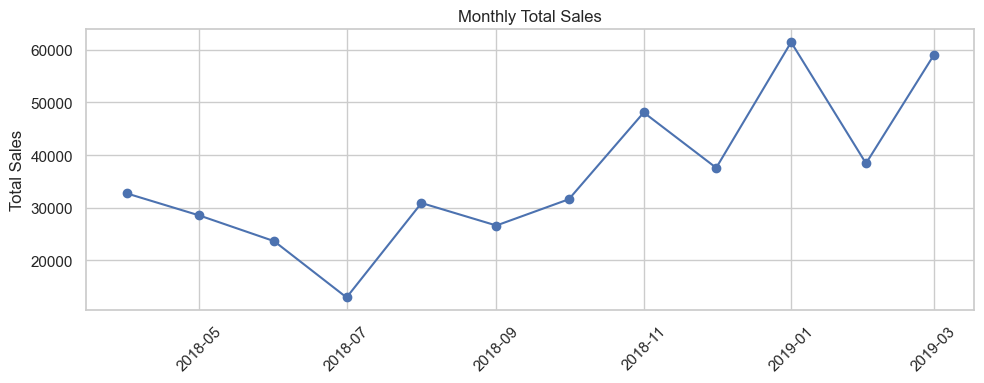

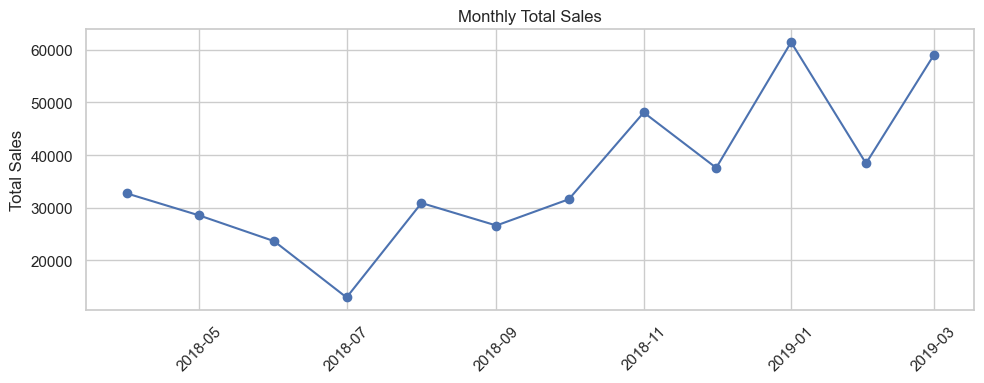

In [5]:
if monthly_trends is not None:
    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(pd.to_datetime(monthly_trends['Year'].astype(str) + '-' + monthly_trends['Month'].astype(str) + '-01'),
            monthly_trends['Total_Sales'], marker='o')
    ax.set_title('Monthly Total Sales')
    ax.set_ylabel('Total Sales')
    plt.xticks(rotation=45)
    plt.tight_layout()
    display(fig)
else:
    print('monthly_trends.csv missing')

### Sales vs Target (Month-level)

If `monthly_sales_vs_target.csv` exists, we show achievement % and a bar/line combo.

,Year,Month,Month_Name,Total_Sales,Total_Profit,Category,Target,Difference,Achievement_pct
0,2018,4,Apr,32726.0,-3960.0,Furniture,10400.0,22326.0,314.673077
1,2018,4,Apr,32726.0,-3960.0,Clothing,12000.0,20726.0,272.716667
2,2018,4,Apr,32726.0,-3960.0,Electronics,9000.0,23726.0,363.622222
3,2018,5,May,28545.0,-3584.0,Furniture,10500.0,18045.0,271.857143
4,2018,5,May,28545.0,-3584.0,Clothing,12000.0,16545.0,237.875000


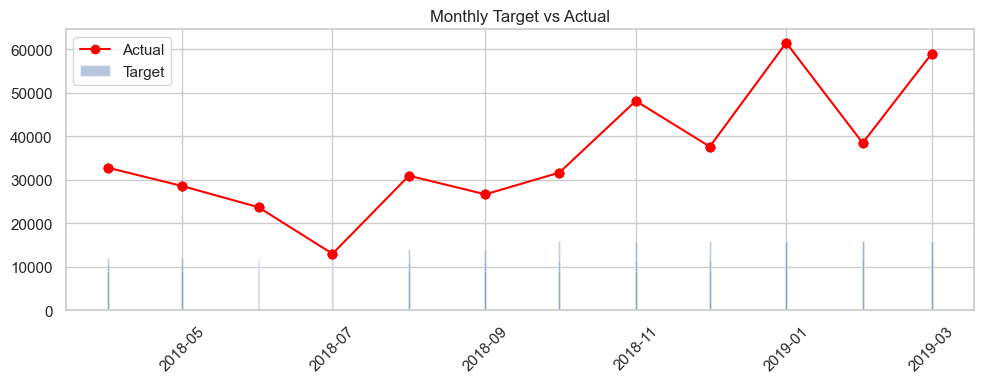

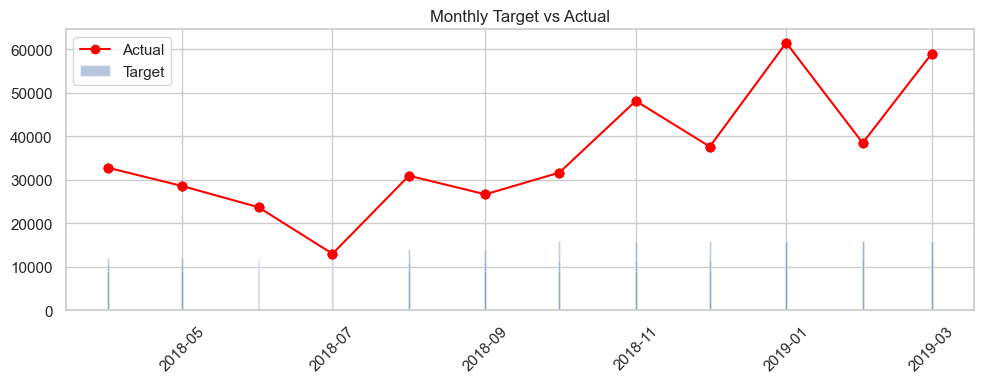

In [7]:
if sales_vs_target is not None:
    display(sales_vs_target.head())
    # plot achieved vs target
    fig, ax = plt.subplots(figsize=(10,4))
    months = pd.to_datetime(sales_vs_target['Year'].astype(str) + '-' + sales_vs_target['Month'].astype(str) + '-01')
    ax.bar(months, sales_vs_target['Target'], alpha=0.4, label='Target')
    ax.plot(months, sales_vs_target['Total_Sales'], marker='o', color='red', label='Actual')
    ax.set_title('Monthly Target vs Actual')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    display(fig)
else:
    print('monthly_sales_vs_target.csv missing')

## Category Performance

Show category revenue and profit and a quick bar chart.

,Category,Amount,Profit
0,Electronics,165267.0,10494.0
1,Clothing,139054.0,11163.0
2,Furniture,127181.0,2298.0


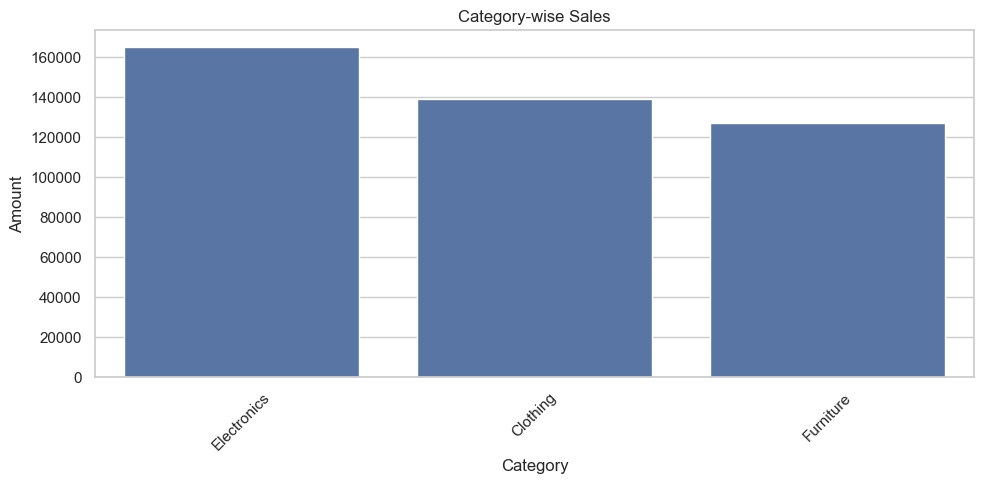

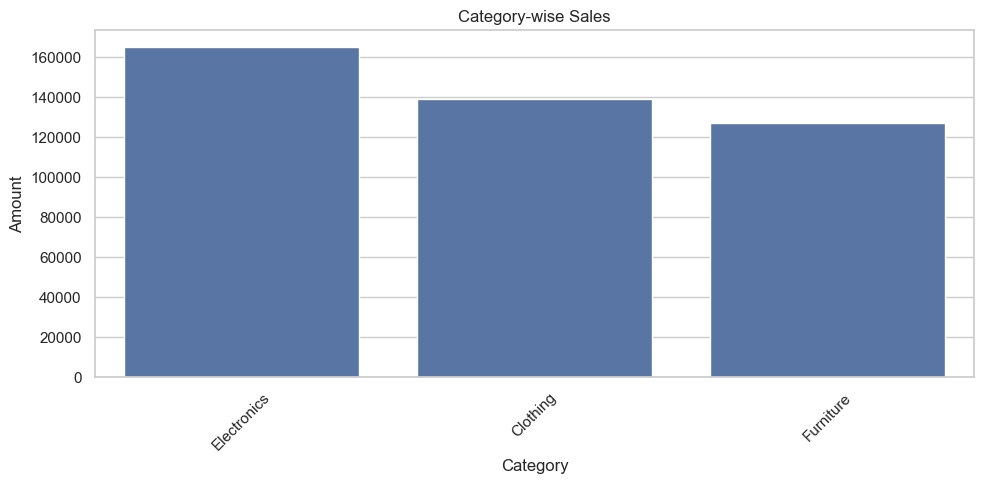

In [8]:
if category_sales is not None:
    display(category_sales.sort_values('Amount', ascending=False).head(10))
    fig, ax = plt.subplots(figsize=(10,5))
    sns.barplot(data=category_sales.sort_values('Amount', ascending=False), x='Category', y='Amount')
    plt.xticks(rotation=45)
    plt.title('Category-wise Sales')
    plt.tight_layout()
    display(fig)
else:
    print('category_sales.csv missing')

## State & Regional Analysis

Top states by revenue and profit.

,State,Amount,Profit
0,Madhya Pradesh,105140.0,5551.0
1,Maharashtra,95348.0,6176.0
2,Delhi,22531.0,2987.0
3,Uttar Pradesh,22359.0,3237.0
4,Rajasthan,21149.0,1257.0
5,Gujarat,21058.0,465.0
6,Punjab,16786.0,-609.0
7,Karnataka,15058.0,645.0
8,West Bengal,14086.0,2500.0
9,Kerala,13459.0,1871.0


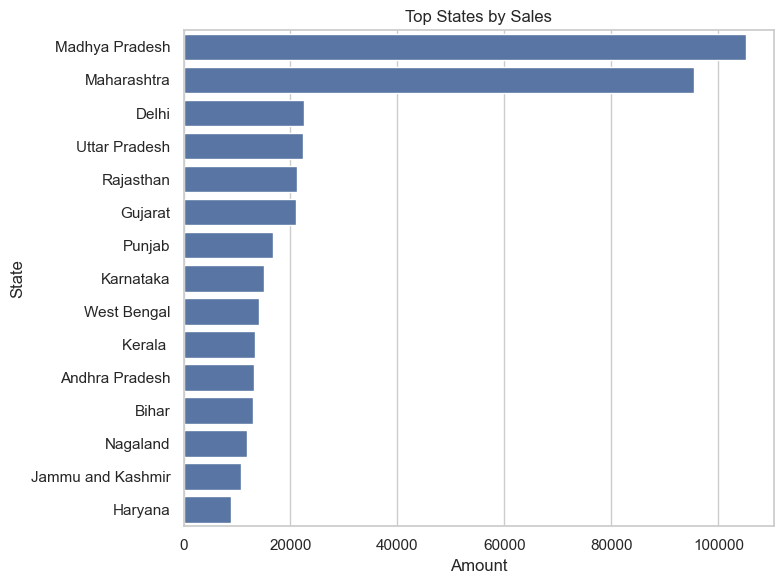

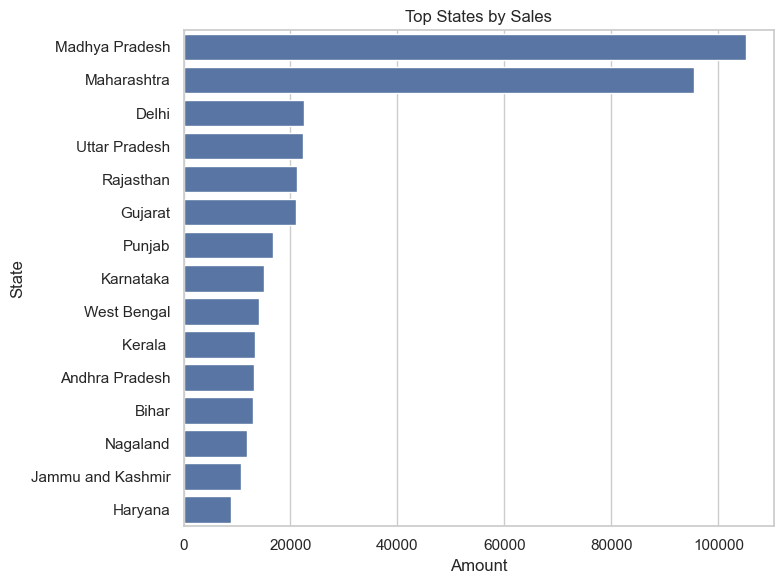

In [9]:
if state_sales is not None:
    display(state_sales.sort_values('Amount', ascending=False).head(10))
    fig, ax = plt.subplots(figsize=(8,6))
    sns.barplot(data=state_sales.sort_values('Amount', ascending=False).head(15), x='Amount', y='State')
    plt.title('Top States by Sales')
    plt.tight_layout()
    display(fig)
else:
    print('state_sales.csv missing')

## Customer Analysis

Top customers, concentration, and recommendations.

,CustomerName,Amount
0,Yaanvi,9177.0
1,Pooja,9030.0
2,Abhishek,8135.0
3,Surabhi,6889.0
4,Soumya,6869.0
5,Harshal,6026.0
6,Priyanka,5762.0
7,Shruti,5750.0
8,Abhijeet,5691.0
9,Sarita,5449.0


Top 10 customers contribute 15.94% of total revenue


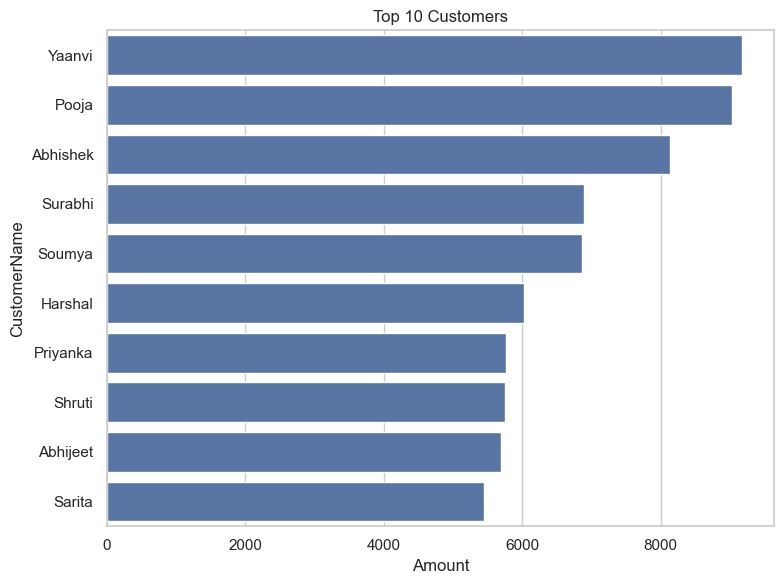

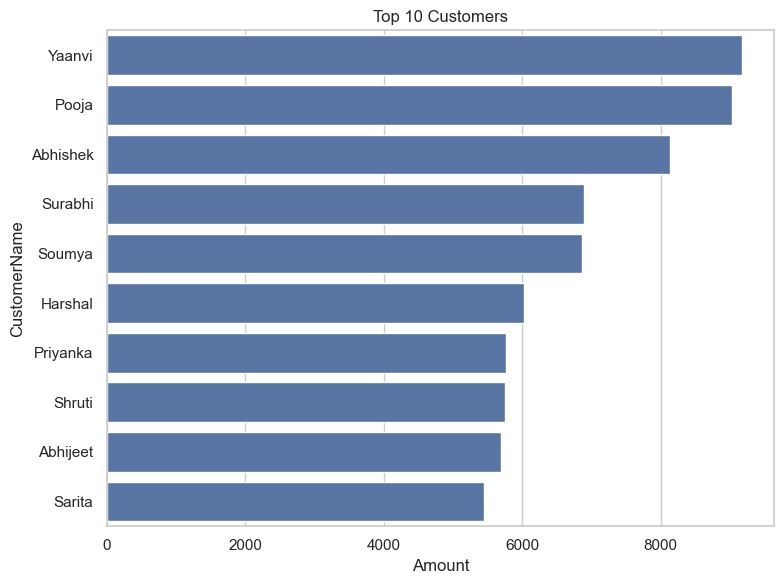

In [10]:
if top_customers is not None:
    display(top_customers.head(10))
    # concentration
    if monthly_trends is not None:
        total_rev = monthly_trends['Total_Sales'].sum()
        top10_sum = top_customers.head(10)['Amount'].sum()
        print(f'Top 10 customers contribute {top10_sum/total_rev:.2%} of total revenue')
    fig, ax = plt.subplots(figsize=(8,6))
    sns.barplot(data=top_customers.head(10), x='Amount', y='CustomerName')
    plt.title('Top 10 Customers')
    plt.tight_layout()
    display(fig)
else:
    print('top_customers.csv missing')

## Profitability Analysis

Category & state profitability and sub-category highlights.

,Category,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_pct
0,Clothing,139054.0,11163.0,3516,8.027817
1,Electronics,165267.0,10494.0,1154,6.349725
2,Furniture,127181.0,2298.0,945,1.806874


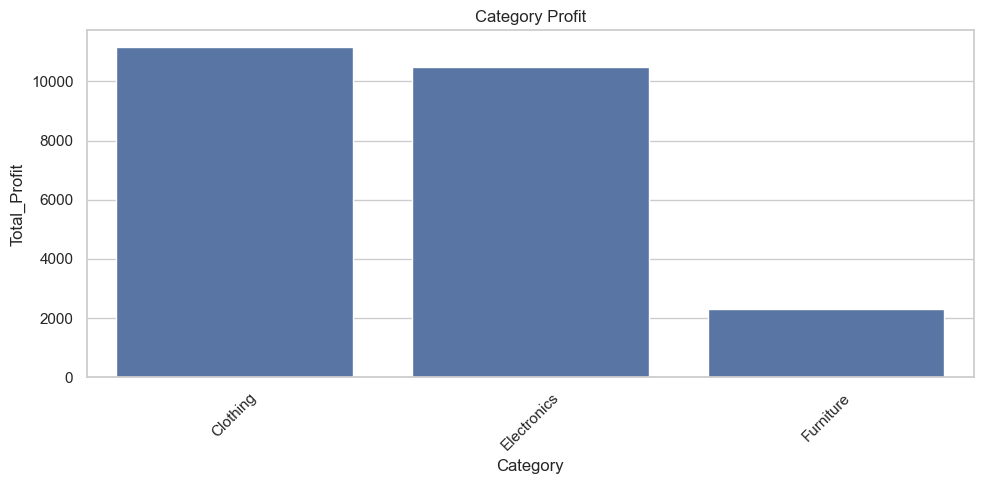

,Sub-Category,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_pct
0,Printers,58252.0,5964.0,291,10.238275
1,Bookcases,56861.0,4888.0,297,8.596402
2,Accessories,21728.0,3559.0,262,16.379786
3,Trousers,30039.0,2847.0,135,9.477679
4,Stole,18546.0,2559.0,671,13.798124


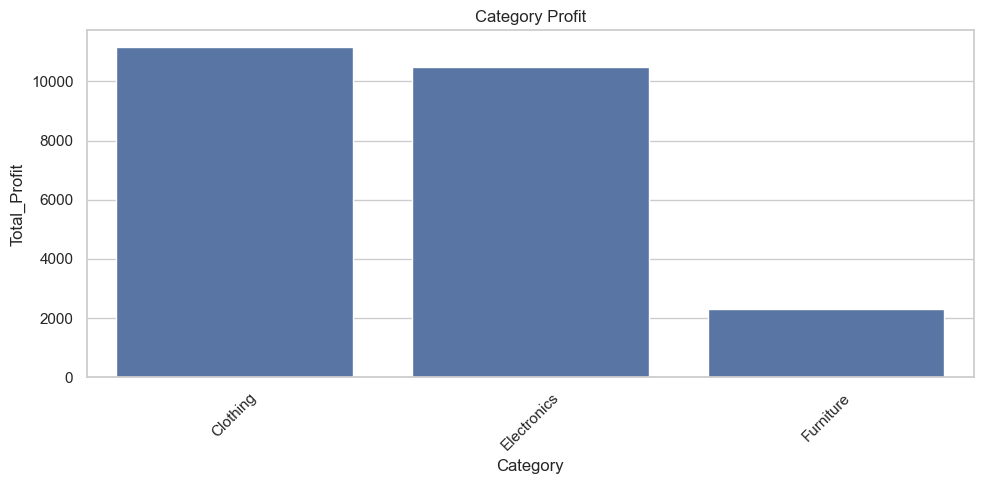

In [11]:
cat_prof_path = os.path.join(OUTPUT_DIR, 'category_profitability.csv')
state_prof_path = os.path.join(OUTPUT_DIR, 'state_profitability.csv')
subcat_top_path = os.path.join(OUTPUT_DIR, 'subcategory_profit_top10.csv')
subcat_bottom_path = os.path.join(OUTPUT_DIR, 'subcategory_profit_bottom10.csv')

if os.path.exists(cat_prof_path):
    cat_prof = pd.read_csv(cat_prof_path)
    display(cat_prof.head())
    fig, ax = plt.subplots(figsize=(10,5))
    sns.barplot(data=cat_prof.sort_values('Total_Profit', ascending=False), x='Category', y='Total_Profit')
    plt.xticks(rotation=45)
    plt.title('Category Profit')
    plt.tight_layout()
    display(fig)
else:
    print('category_profitability.csv not found')

if os.path.exists(subcat_top_path):
    display(pd.read_csv(subcat_top_path).head())
else:
    print('subcategory profit files not found - computed earlier?')

## Visualizations (Embedded from outputs/plots)

Below are the saved plot images produced by `scripts/visualizations.py`. These are included as images (so viewers on GitHub can see them without running code).

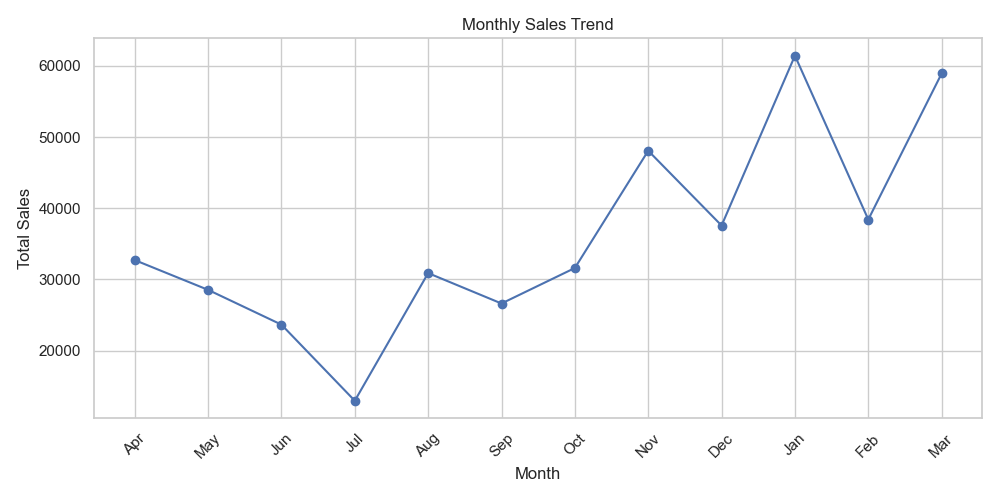

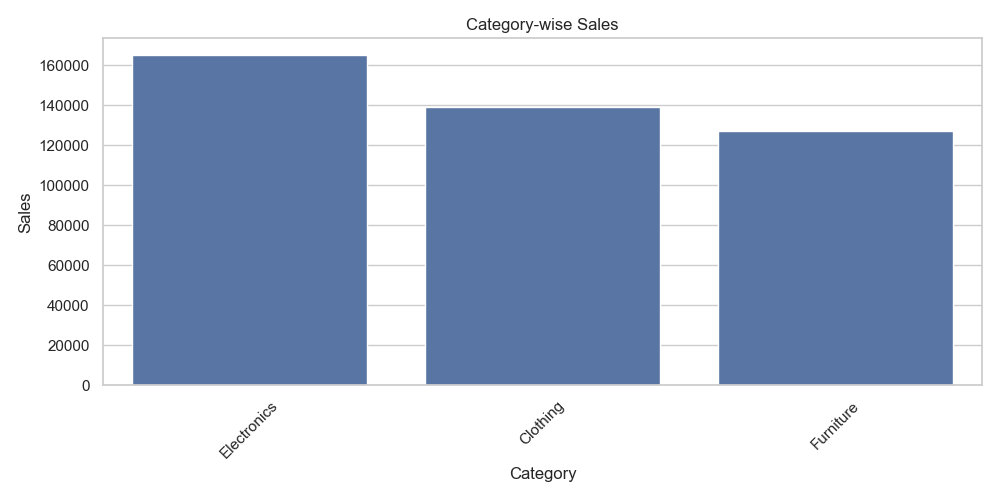

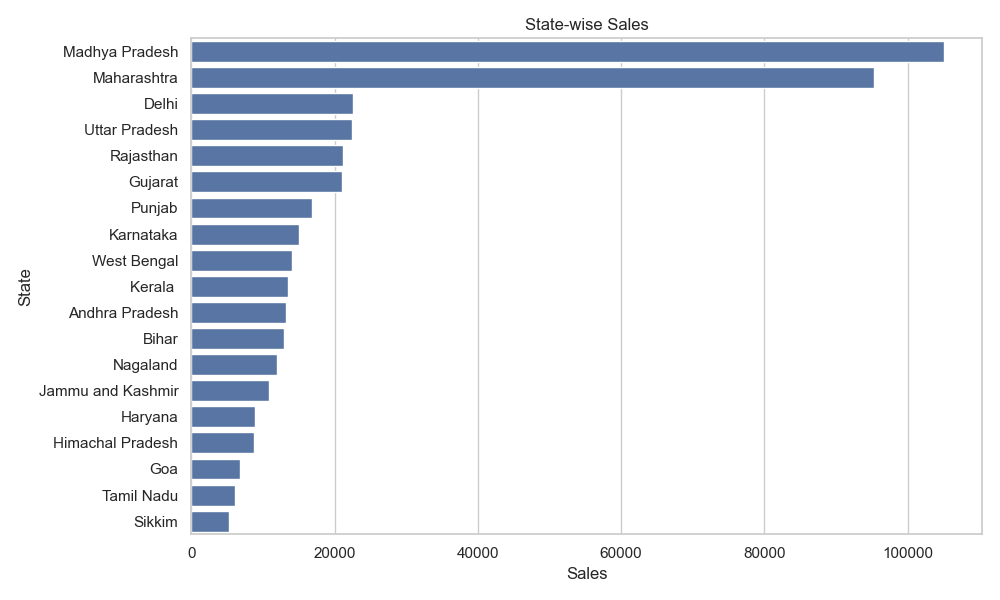

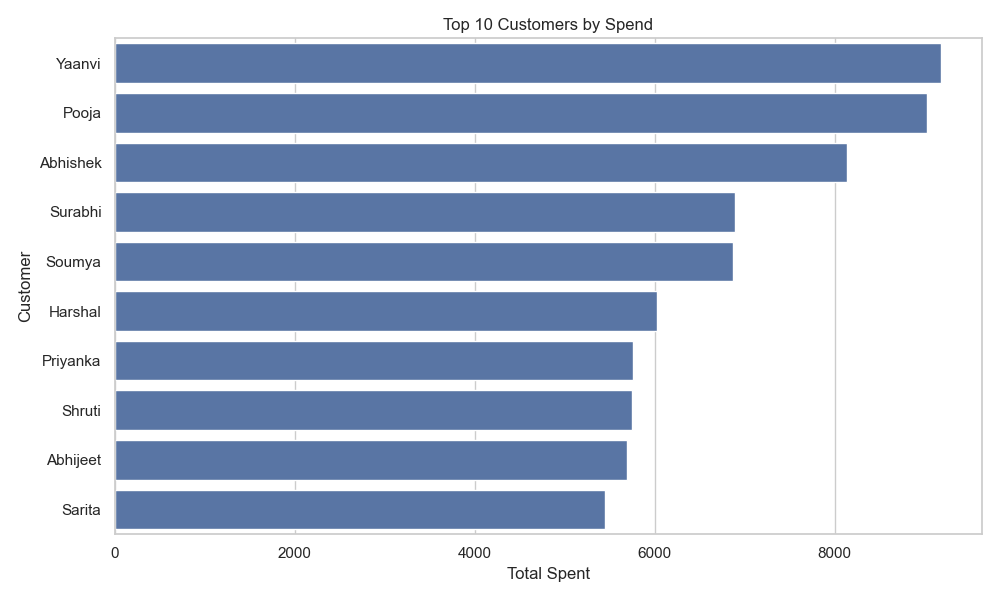

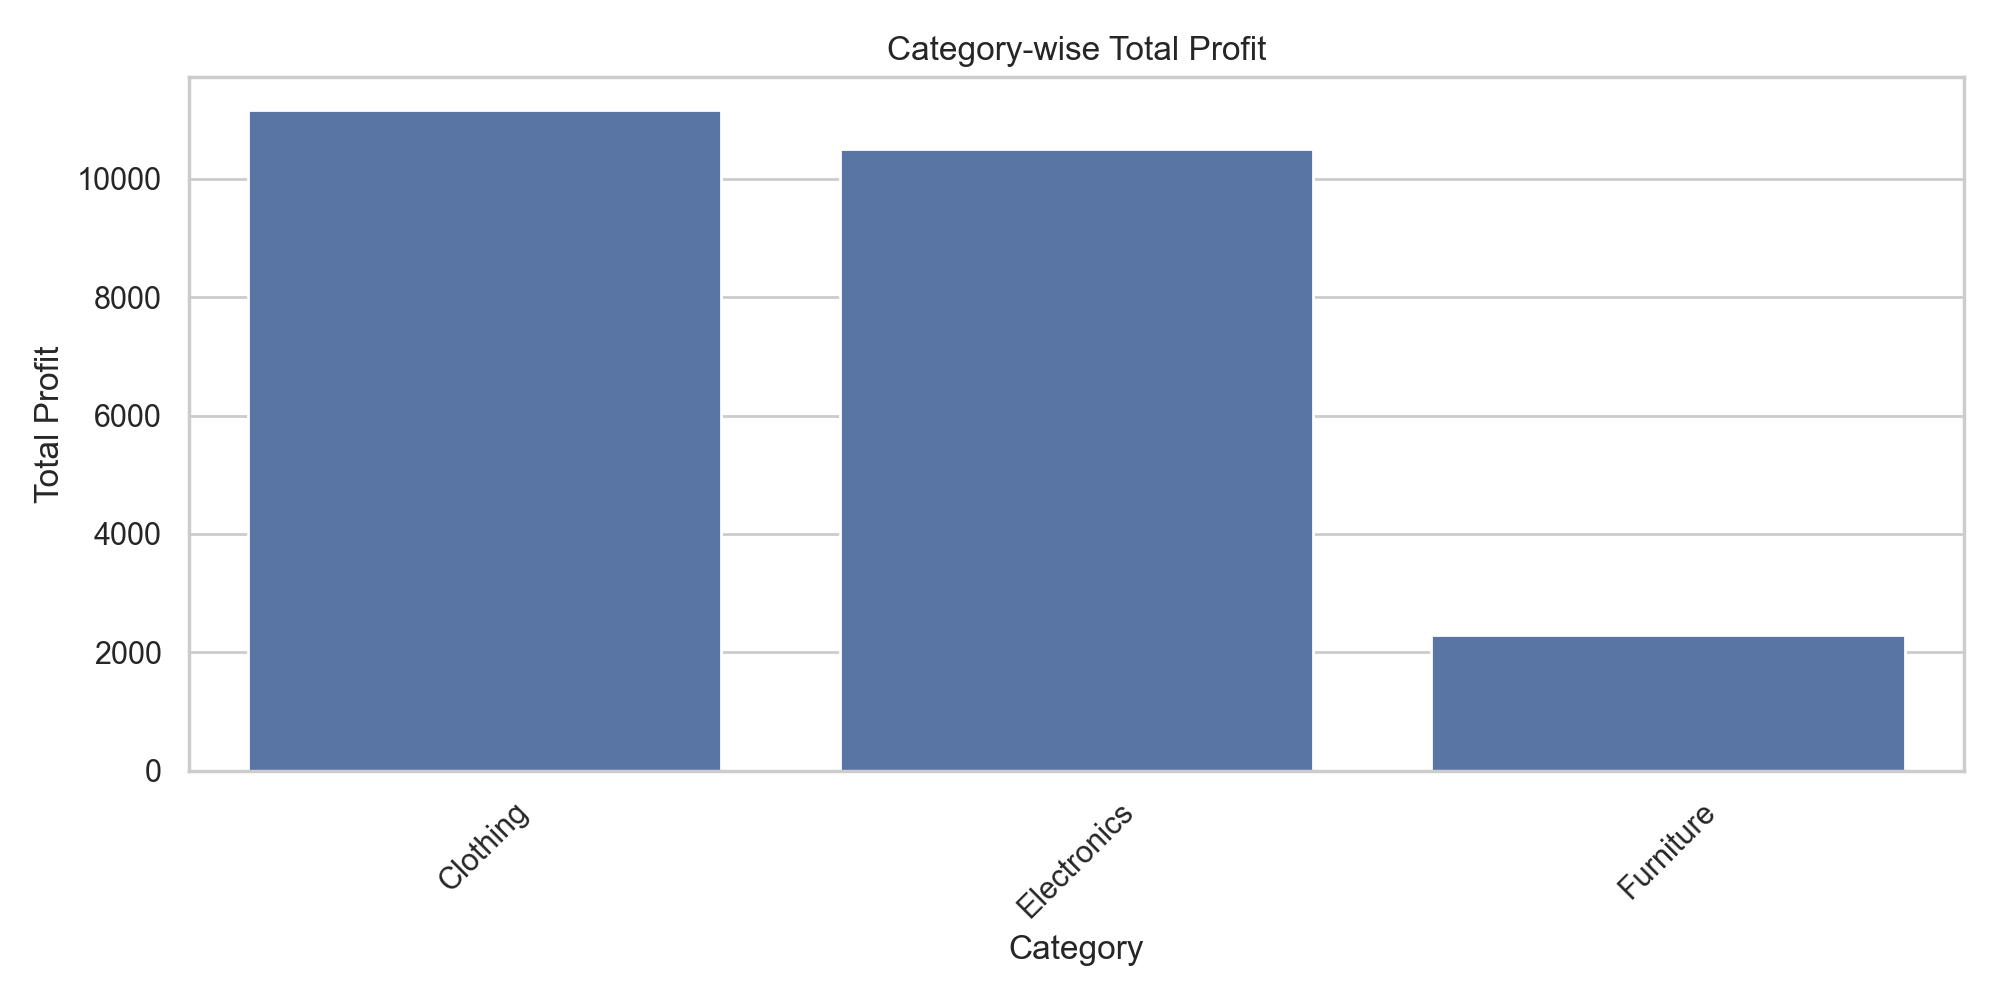

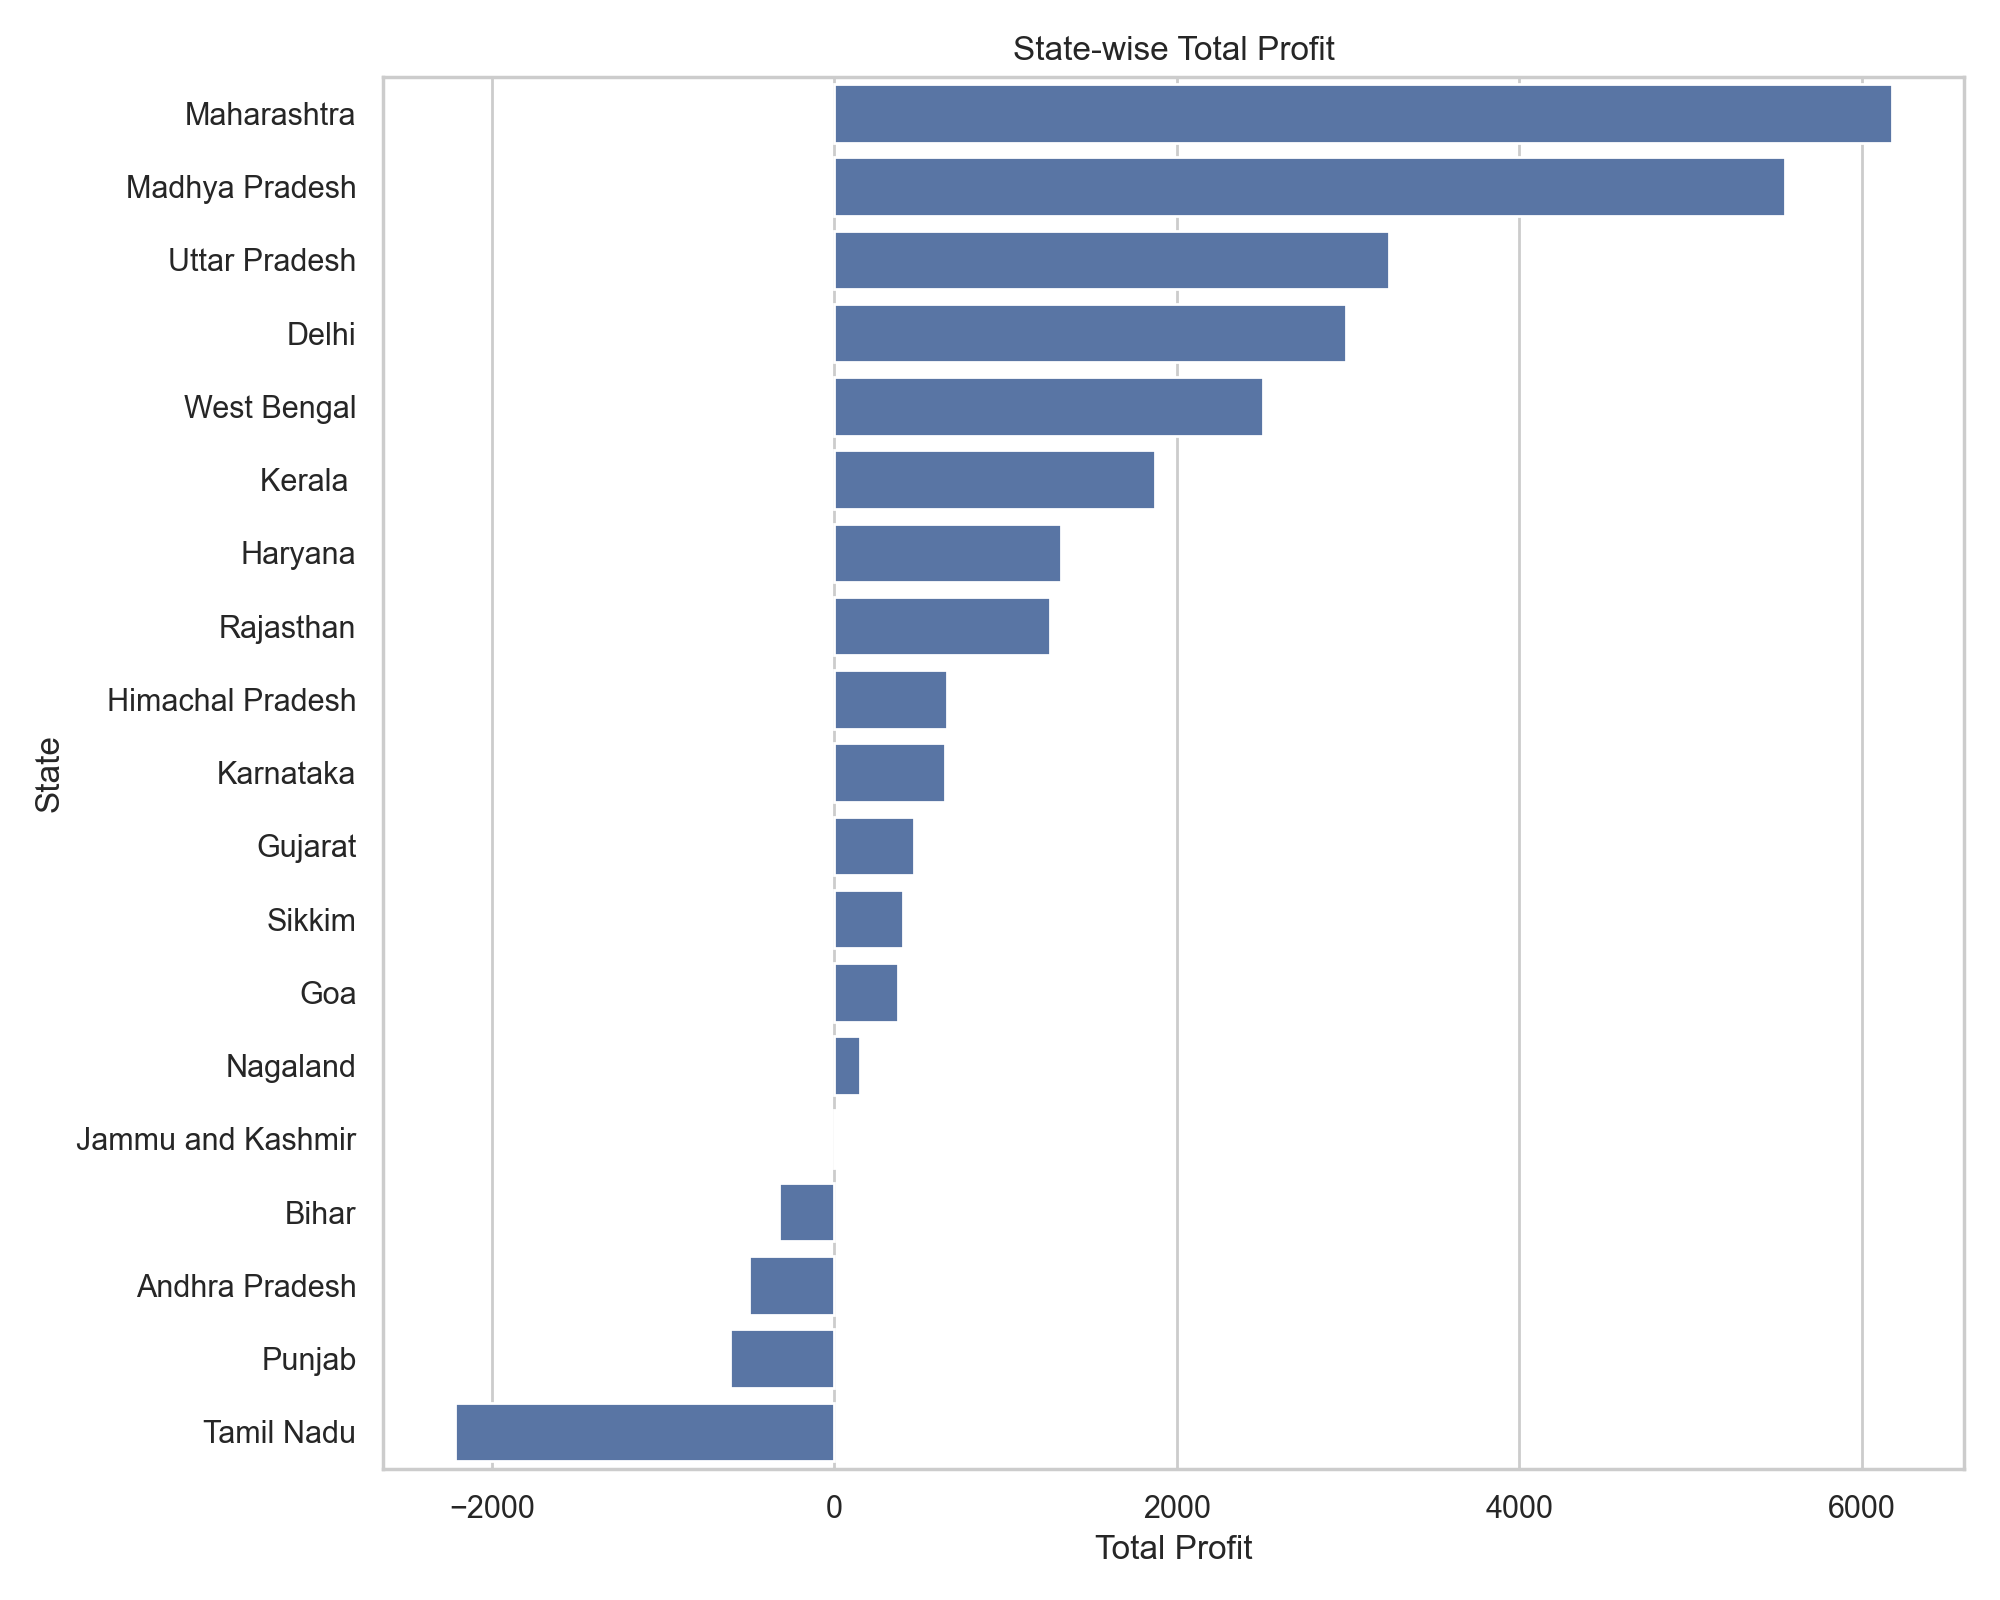

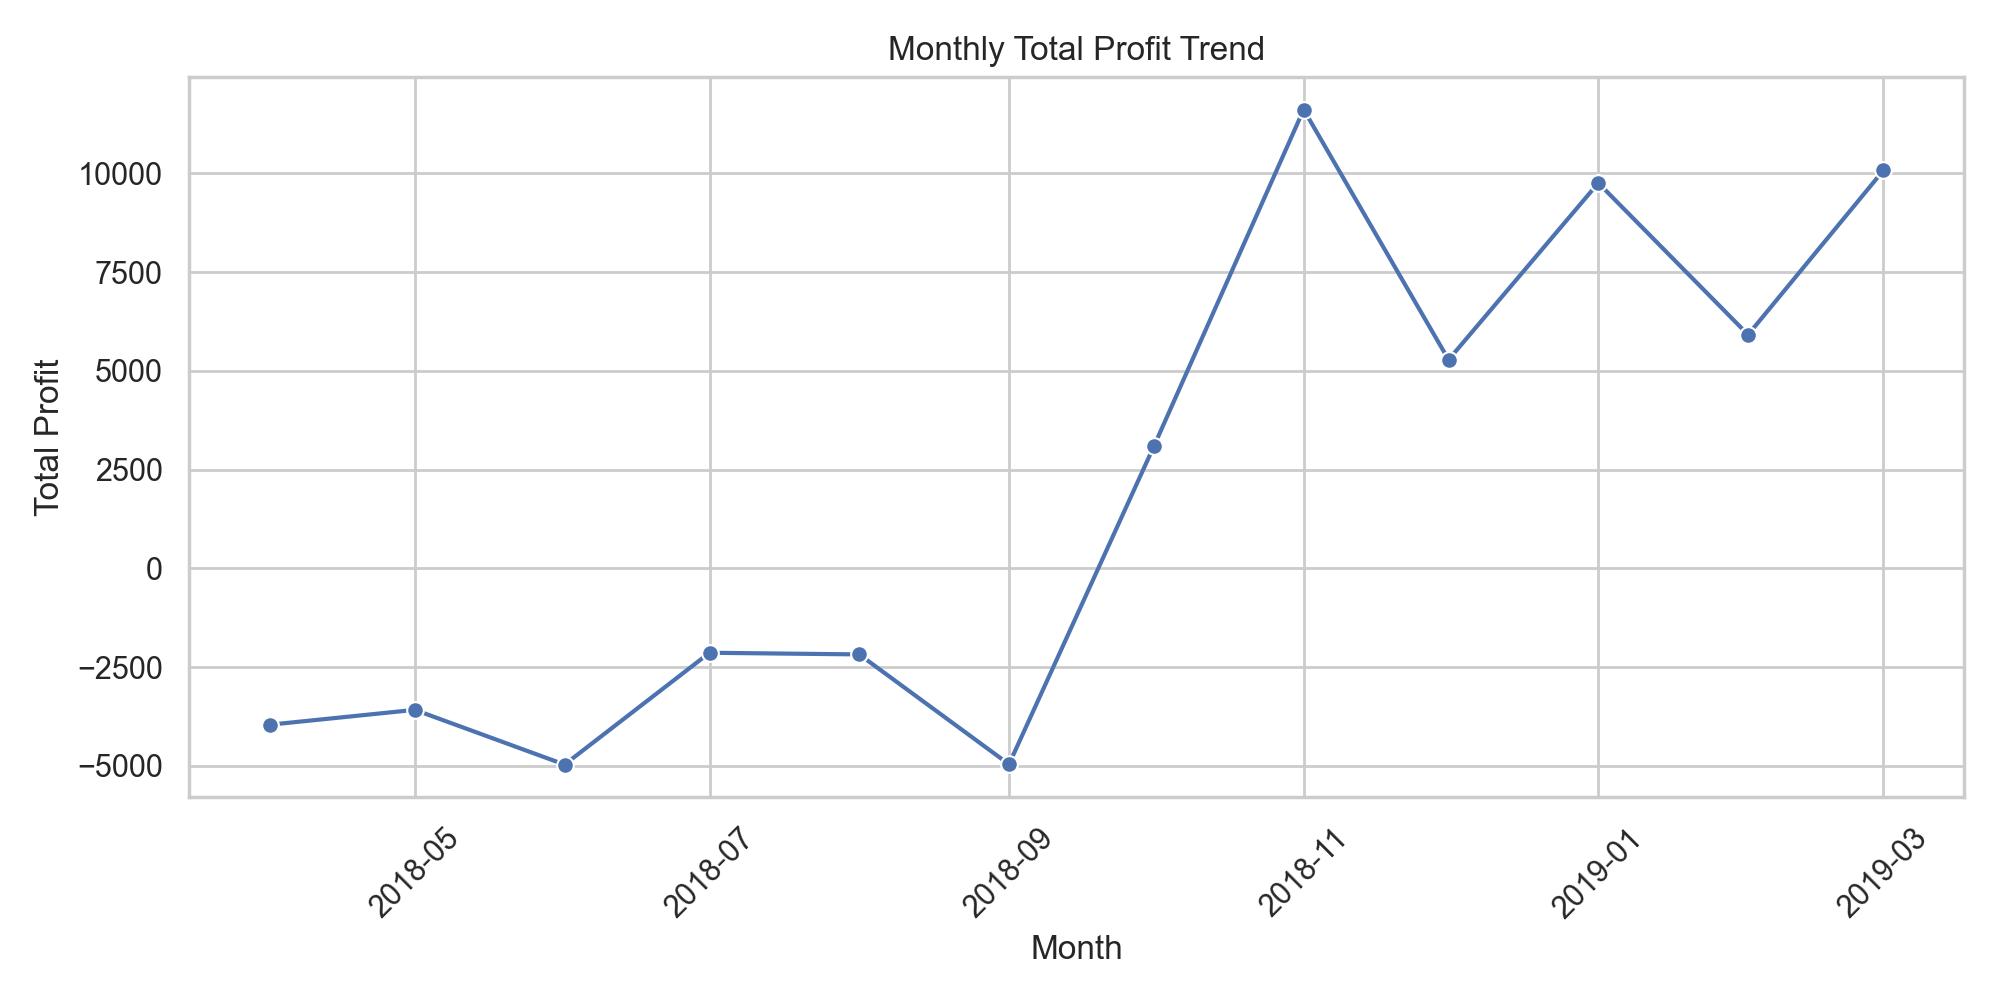

In [12]:
plots = ['monthly_sales_trend.png','category_sales.png','state_sales.png','top_customers.png',
         'category_profit.png','state_profit.png','monthly_profit_trend.png']
for p in plots:
    path = os.path.join(PLOTS_DIR, p)
    if os.path.exists(path):
        display(Image(path, width=700))
    else:
        print('Missing:', p)

## Power BI Dashboard (Screenshots)

If you created a Power BI dashboard, add 1–3 screenshots under `powerbi/dashboard_screenshots/`. They will be displayed below when present.

In [13]:
pb_dir = os.path.join(BASE_DIR, 'powerbi', 'dashboard_screenshots')
if os.path.exists(pb_dir):
    for f in os.listdir(pb_dir):
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            display(Image(os.path.join(pb_dir, f), width=700))
else:
    print('No Power BI screenshots found. Add screenshots to powerbi/dashboard_screenshots/')

No Power BI screenshots found. Add screenshots to powerbi/dashboard_screenshots/


## SQL Snippets (Reference)

Below are example SQL queries you should include in the `/sql` folder. They are shown here for quick reference. Save them as `.sql` files in that folder.

In [15]:
print('Example SQL queries (save in /sql/*.sql):')
print('''
-- Top 10 customers by revenue
SELECT CustomerName, SUM(Amount) AS total_spent
FROM orders
GROUP BY CustomerName
ORDER BY total_spent DESC
LIMIT 10;

-- Monthly revenue and profit
SELECT YEAR(`Order Date`) AS yr, MONTH(`Order Date`) AS mon, SUM(Amount) AS total_sales, SUM(Profit) AS total_profit
FROM orders
GROUP BY yr, mon
ORDER BY yr, mon;

-- State-wise performance
SELECT State, SUM(Amount) AS total_sales, SUM(Profit) AS total_profit
FROM orders
GROUP BY State
ORDER BY total_sales DESC;
''')

Example SQL queries (save in /sql/*.sql):

-- Top 10 customers by revenue
SELECT CustomerName, SUM(Amount) AS total_spent
FROM orders
GROUP BY CustomerName
ORDER BY total_spent DESC
LIMIT 10;

-- Monthly revenue and profit
SELECT YEAR(`Order Date`) AS yr, MONTH(`Order Date`) AS mon, SUM(Amount) AS total_sales, SUM(Profit) AS total_profit
FROM orders
GROUP BY yr, mon
ORDER BY yr, mon;

-- State-wise performance
SELECT State, SUM(Amount) AS total_sales, SUM(Profit) AS total_profit
FROM orders
GROUP BY State
ORDER BY total_sales DESC;



## Conclusions & Next Steps

- Summarize the key takeaways (best months, best categories, top states, customer concentration).
- Suggested next steps: Power BI interactive dashboard, deeper cohort / retention analysis, A/B test for discount strategies.

---

*Notebook generated automatically by the assistant. Edit text cells to add more business context before sharing.*